In [104]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim  as optim

import torchvision
import torchvision.transforms as transforms

import cv2
import matplotlib.pyplot as plt
from jedi.inference.cache import inference_state_method_generator_cache


In [105]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())
device = torch.device('cuda')

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [106]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [107]:
train_data = torchvision.datasets.CIFAR10(root='./data',train=True,transform=transform,download=True)
test_data = torchvision.datasets.CIFAR10(root='./data',train=False,transform=transform,download=True)


In [108]:
image,label = train_data[0]

In [109]:
img, label = train_data[8]
print(img.shape)              # torch.Size([3, 32, 32]) C,H,W

img_np = img.permute(1, 2, 0).numpy()
print(img_np.shape)           # (32, 32, 3)  H,W,C

torch.Size([3, 32, 32])
(32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.9764706].


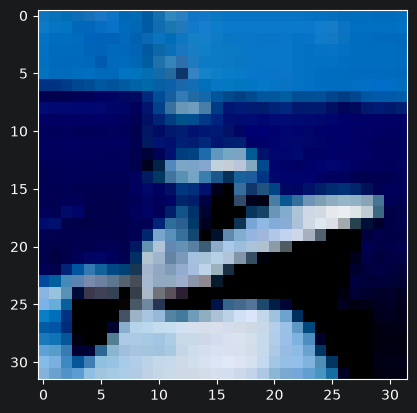

In [110]:
plt.imshow(img_np)
plt.show()

In [111]:
class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

In [112]:
# dataset loader
train_loader = torch.utils.data.DataLoader(train_data,batch_size=32,shuffle=True,num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=32,shuffle=True,num_workers=2)

In [121]:
class Hnet(nn.Module):
    def __init__(self,input_features):
        super().__init__()
        self.convolution = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512,out_channels=512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.Classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=512*2*2,out_features=128),
            nn.Dropout(0.4),
            nn.Linear(in_features=128,out_features=64),
            nn.Linear(in_features=64,out_features=10)
        )

    def forward(self,x):
        x = self.convolution(x)
        x = self.Classifier(x)
        return x





In [125]:
learning_rate = 0.01
epochs = 60

In [126]:
model = Hnet(3)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr = learning_rate,weight_decay=5e-4,momentum=0.9)

In [127]:
# training loop
for  epoch in range(epochs):
    print(f"training epoch : {epoch}")
    running_loss = 0.0
    for i,data in enumerate(train_loader):
        inputs,label = data
        # Move data to the GPU
        inputs = inputs.to(device)
        label = label.to(device)
        # gradient reset
        optimizer.zero_grad()
        # output
        output = model(inputs)
        # loss
        loss = criterion(output,label)
        loss.backward()
        #optimizer
        optimizer.step()

        running_loss +=loss.item()
    print(f"loss: {running_loss/len(train_loader):.4f}")

training epoch : 0
loss: 1.3233
training epoch : 1
loss: 0.8365
training epoch : 2
loss: 0.6537
training epoch : 3
loss: 0.5277
training epoch : 4
loss: 0.4353
training epoch : 5
loss: 0.3624
training epoch : 6
loss: 0.3057
training epoch : 7
loss: 0.2578
training epoch : 8
loss: 0.2178
training epoch : 9
loss: 0.1872
training epoch : 10
loss: 0.1678
training epoch : 11
loss: 0.1498
training epoch : 12
loss: 0.1342
training epoch : 13
loss: 0.1348
training epoch : 14
loss: 0.1170
training epoch : 15
loss: 0.1150
training epoch : 16
loss: 0.1132
training epoch : 17
loss: 0.1042
training epoch : 18
loss: 0.1045
training epoch : 19
loss: 0.1017
training epoch : 20
loss: 0.0969
training epoch : 21
loss: 0.0983
training epoch : 22
loss: 0.0985
training epoch : 23
loss: 0.0958
training epoch : 24
loss: 0.0922
training epoch : 25
loss: 0.0868
training epoch : 26
loss: 0.0939
training epoch : 27
loss: 0.0884
training epoch : 28
loss: 0.0856
training epoch : 29
loss: 0.0943
training epoch : 30


In [128]:
torch.save(model.state_dict(),'trained_net.pth')

In [129]:
net = Hnet(3)
net.load_state_dict((torch.load('trained_net.pth')))

<All keys matched successfully>

In [130]:
correct = 0
total =0
net.eval()

with torch.no_grad():
    for data in test_loader:
        images,labels = data
        outputs = net(images)
        _,predicted = torch.max(outputs,1)
        #print(predicted,labels)
        total+= labels.size(0)
        correct+=(predicted==labels).sum().item()

accuracy = 100*correct/total
print(f" accuracy :{accuracy}")

 accuracy :82.87


In [131]:
new_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])
def load_image(image_path):
    image = Image.open(image_path)
    image = new_transform(image)
    image = image.unsqueeze(0)
    return  image

image_path = 'plane.jpg'
img = load_image(image_path)
img.shape


torch.Size([1, 3, 32, 32])

In [132]:
net.eval()
with torch.no_grad():
    out = net(img)
    _,predicted = torch.max(out,1)
    print(f"prediction: {class_names[predicted.item()]}")


prediction: plane
